<a href="https://colab.research.google.com/github/samueldar07/DAAEX/blob/main/DAA_EP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Array: [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
Min: 0, Max: 9
D&C Comparisons: 14
Naive Comparisons: 18


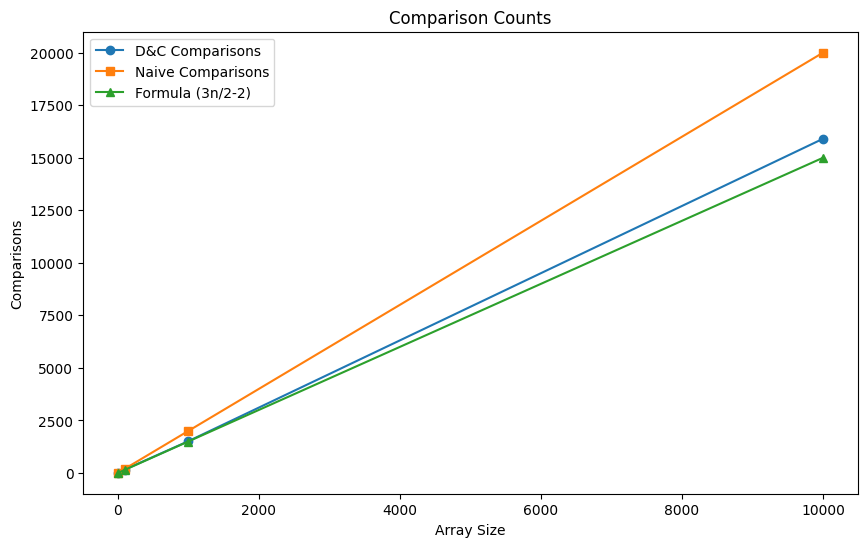

In [1]:
import random
import matplotlib.pyplot as plt #type:ignore

comparison_count = 0  # Global counter

def min_max_dc(arr, low, high):
    global comparison_count
    # Base case: single element
    if low == high:
        return arr[low], arr[low]

    # Base case: two elements
    if high == low + 1:
        comparison_count += 1
        if arr[low] < arr[high]:
            return arr[low], arr[high]
        return arr[high], arr[low]

    # Divide
    mid = (low + high) // 2
    lmin, lmax = min_max_dc(arr, low, mid)
    rmin, rmax = min_max_dc(arr, mid + 1, high)

    # Conquer: combine with 2 comparisons
    comparison_count += 1
    overall_min = lmin if lmin < rmin else rmin
    comparison_count += 1
    overall_max = lmax if lmax > rmax else rmax
    return overall_min, overall_max

def min_max_naive(arr):
    mn, mx = arr[0], arr[0]
    comps = 0
    for x in arr[1:]:
        comps += 1
        if x < mn:
            mn = x
        comps += 1
        if x > mx:
            mx = x
    return mn, mx, comps

# --- Demonstration on small array ---
arr = [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
comparison_count = 0
mn, mx = min_max_dc(arr, 0, len(arr) - 1)
dc_comps = comparison_count
_, _, naive_comps = min_max_naive(arr)

print(f'Array: {arr}')
print(f'Min: {mn}, Max: {mx}')
print(f'D&C Comparisons: {dc_comps}')
print(f'Naive Comparisons: {naive_comps}')

# --- Performance Analysis ---
sizes = [10, 100, 1000, 10000]
dc_comps_list = []
naive_comps_list = []
formula_comps_list = []
for size in sizes:
    arr = [random.randint(1, 10000) for _ in range(size)]
    comparison_count = 0
    mn, mx = min_max_dc(arr, 0, len(arr) - 1)
    dc = comparison_count
    _, _, naive = min_max_naive(arr)
    formula = 3 * size // 2 - 2
    dc_comps_list.append(dc)
    naive_comps_list.append(naive)
    formula_comps_list.append(formula)

plt.figure(figsize=(10, 6))
plt.plot(sizes, dc_comps_list, label='D&C Comparisons', marker='o')
plt.plot(sizes, naive_comps_list, label='Naive Comparisons', marker='s')
plt.plot(sizes, formula_comps_list, label='Formula (3n/2-2)', marker='^')
plt.title('Comparison Counts')
plt.xlabel('Array Size')
plt.ylabel('Comparisons')
plt.legend()
plt.show()